# Técnicas avanzadas de diseño de software

## CUPID & GRASP

----
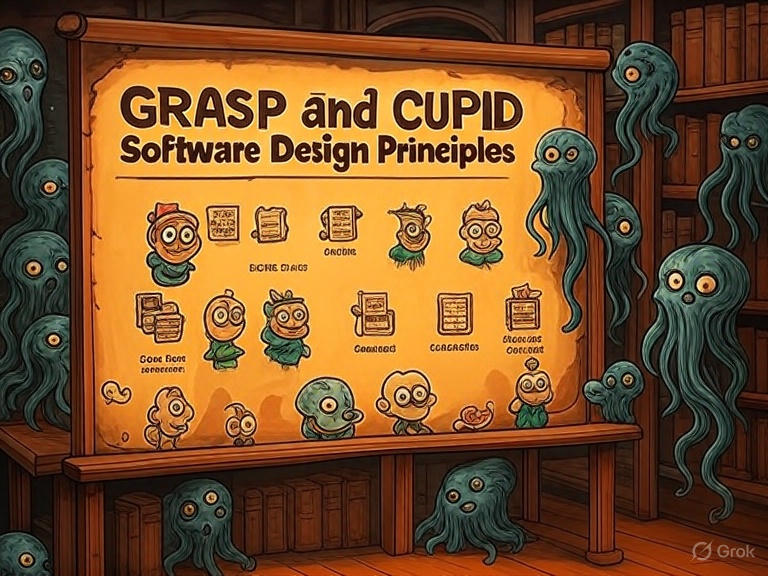


# CUPID - Introducción

**CUPID** es un conjunto de principios propuesto por **Dan North** como una alternativa moderna a SOLID.

## Características:

- Enfoque más **pragmático** y menos dogmático
- Se centra en **propiedades del código** más que reglas estrictas
- Adaptado a **prácticas modernas** de desarrollo
- Fácil de **recordar y aplicar**

**C-U-P-I-D**

# C - Composable (Componible)

## El código debe ser fácil de combinar y reutilizar

**Principio:** Los componentes deben funcionar bien tanto individualmente como cuando se combinan con otros.

In [ ]:
# No composable
class EmailService:
    def send_welcome_email(self):
        # logica especifica
        pass
    
    def send_password_reset_email(self):
        # logica especifica
        pass

# Composable
class EmailTemplate:
    def create_template(self, type): pass

class EmailSender:
    def send(self, template, recipient): pass

class EmailService:
    def __init__(self, template_service, sender):
        self.template = template_service
        self.sender = sender


# U - Unix Philosophy

## "Haz una cosa y hazla bien"

**Principio:** Cada componente debe tener una responsabilidad clara y específica.

In [ ]:
# Hace demasiadas cosas
class UserManager:
    def validate_user(self): pass
    def save_user(self): pass
    def send_email(self): pass
    def generate_report(self): pass

# Una responsabilidad cada uno
class UserValidator:
    def validate(self): pass

class UserRepository:
    def save(self): pass

class NotificationService:
    def send(self): pass

class ReportGenerator:
    def generate(self): pass


# P - Predictable (Predecible)

## El comportamiento debe ser consistente y esperado

**Principio:** El código debe comportarse de manera que los desarrolladores puedan anticipar qué hará.

- **Nombres descriptivos** y consistentes
- **Comportamiento uniforme** en situaciones similares
- **Evitar efectos secundarios** inesperados
- **Manejo consistente** de errores

In [ ]:
def calculate_tax(amount):
    if amount < 0:
        raise ValueError('Invalid amount')
    return amount * 0.21


# I - Idiomatic (Idiomático)

## Seguir las convenciones naturales del lenguaje

**Principio:** El código debe sentirse natural en el lenguaje y framework que estás usando.

In [ ]:
# Python idiomatico
users = [fetch_user(user_id) for user_id in user_ids]

# Context manager
with open('file.txt', 'r') as file:
    content = file.read()

# List comprehension
valid_users = [user for user in users if user.is_active]

# Dictionary comprehension
user_dict = {user.id: user.name for user in users}


# D - Domain-based (Basado en el Dominio)

## Organizado alrededor del problema del negocio

**Principio:** La estructura del código debe reflejar el dominio del problema, no la tecnología.

In [ ]:
# Organizado por tecnología
/controllers/
/services/
/repositories/

# Organizado por dominio
/user/
  - user_controller.py
  - user_service.py
  - user_repository.py
/order/
  - order_controller.py
  - order_service.py
  - order_repository.py


# GRASP - Introducción

**GRASP** (General Responsibility Assignment Software Patterns) son patrones fundamentales para asignar responsabilidades en el diseño orientado a objetos.

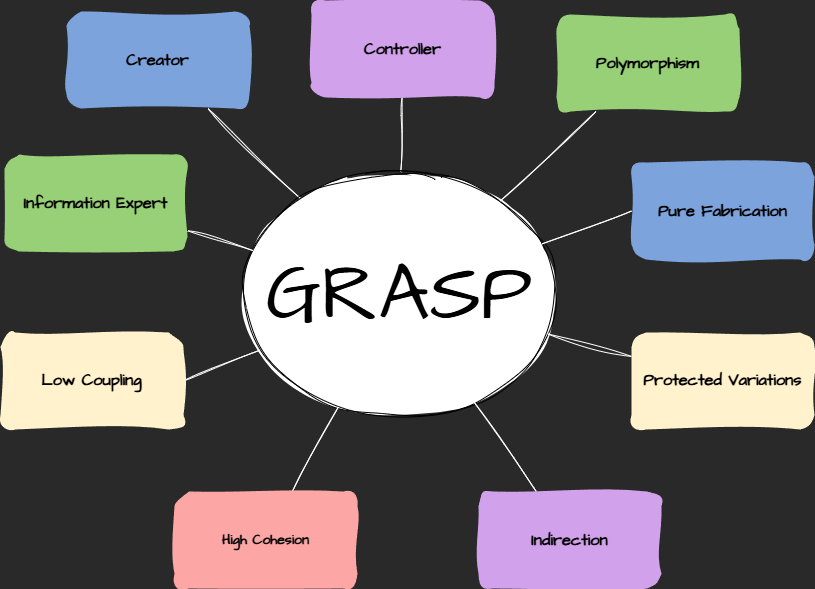


## Características:

- **9 patrones fundamentales** de diseño
- Enfocado en **asignación de responsabilidades**
- Base teórica sólida para **programación orientada a objetos**
- Principios **atemporales** y bien establecidos

# GRASP - Patrones Básicos

## Information Expert
Asignar responsabilidades a la clase que tiene la información necesaria.

## Creator
Determinar quién debe crear instancias de objetos.

## Controller
Manejar eventos del sistema de manera coordinada.

In [ ]:
class Order:
    def __init__(self):
        self.items = []
    
    def calculate_total(self):  # Information Expert
        return sum(item.get_price() for item in self.items)
    
    def create_order_item(self, product):  # Creator
        return OrderItem(product, self)


# GRASP - Patrones de Calidad

## Low Coupling (Bajo Acoplamiento)
Minimizar dependencias entre clases.

## High Cohesion (Alta Cohesión)
Mantener elementos relacionados juntos.

**Bajo Acoplamiento:** Las clases no dependen mucho unas de otras.

**Alta Cohesión:** Los métodos de una clase trabajan juntos hacia un objetivo común.

In [ ]:
# Alta cohesion - todos los metodos relacionados con User
class User:
    def validate_email(self): pass
    def hash_password(self): pass
    def update_profile(self): pass


# GRASP - Patrones Avanzados

## Polymorphism
Usar polimorfismo para manejar variaciones en comportamiento.

## Pure Fabrication
Crear clases artificiales para mantener bajo acoplamiento.

## Indirection
Usar intermediarios para reducir acoplamiento directo.

## Protected Variations
Proteger elementos estables de los cambios.

In [ ]:
from abc import ABC, abstractmethod

class PaymentProcessor(ABC):
    @abstractmethod
    def process(self, amount):
        pass

class CreditCardProcessor(PaymentProcessor):
    def process(self, amount):
        # procesar tarjeta de credito
        return True

class PayPalProcessor(PaymentProcessor):
    def process(self, amount):
        # procesar PayPal
        return True
